# A Supply Chain Analytics Approach to Price Forecasting for Karnataka's TOP Crops: Reducing Oversupply Risk Through Data-Driven Farm Planning

### Interim Report

**Alvis Lazarus A**
Walsh College
QM640: Data Analytics Capstone
Pralhad Teggi
Term 3

---

**How this notebook is organized.** Section headings below follow the interim report
grading rubric section by section (Introduction, Literature Survey, Data Description,
Analysis, Modelling, Preliminary Results, Bibliography) so that each rubric row can be
checked directly against the corresponding section. Every table and figure is produced by
the code in this notebook from the four raw source files described in the Data Description
section -- nothing here is pasted in from an external analysis. Cells are meant to be run
top to bottom; a few later cells (SARIMA fitting, the walk-forward XGBoost loop) take a
minute or two on Colab's default CPU runtime, which is noted where it applies.

## 1. Introduction, Scope & Objectives

### 1.1 Background and context

Onion, tomato, and potato -- referred to throughout this report as Karnataka's "TOP crops"
-- are among the state's most heavily traded and most price-volatile horticultural
commodities, moving through the APMC (Agricultural Produce Market Committee) mandi network.
Unlike MSP-backed cereal staples, these three crops are perishable and largely outside
Minimum Support Price protection, which leaves growers fully exposed to short-run supply
and demand shocks. A single bad month of oversupply can wipe out a season's margin, and
there is currently no widely available tool that turns a price forecast into a concrete,
farm-level planting decision for these crops in Karnataka specifically.

The modelling choice in this report is informed directly by the literature reviewed below:
Sable et al. (2024) benchmarked fourteen algorithms on five years of Mumbai APMC price data
and found XGBoost the strongest performer (R² = 0.972), and Dharavath and Khosla (2019)
validated seasonal ARIMA specifically on Bengaluru, Karnataka price data. That is the reason
this project pairs an XGBoost model against a SARIMA baseline rather than a more exotic
alternative -- both choices are grounded in prior work on data that looks like this project's
data, not picked for novelty.

### 1.2 Problem statement

Karnataka's TOP-crop growers remain exposed to price volatility and recurring oversupply
cycles because no existing, published tool converts a price forecast into an actionable,
farm-level planting decision for this specific crop set and geography. Price-forecasting
work such as Sable et al. (2024) predicts mandi prices accurately but stops short of a
profit figure a farmer could act on. Crop-recommendation work such as Sam and D'Abreo (2025)
and Dwibedy et al. (2026) does incorporate economic variables, but at a multi-state or
single-market resolution too coarse to reflect Karnataka's district-level mandi and rainfall
patterns. No published study forecasts onion, tomato, and potato for Karnataka as a grouped
set, benchmarks that forecast against naive and SARIMA baselines under a validation protocol
that avoids look-ahead leakage, and converts the result into a profit-ranked, uncertainty-aware
recommendation. That is the gap this project addresses.

### 1.3 Purpose of the study

The purpose of this study is fourfold:

1. **Predict** monthly wholesale (modal) mandi prices for onion, tomato, and potato across
   four of Karnataka's major producing districts using an XGBoost regression model,
   benchmarked against a seasonal-naive baseline and a SARIMA baseline.
2. **Explain** which agronomic, temporal, and economic features -- rainfall, seasonality,
   lagged price, and cost of cultivation -- drive those forecasts, and test whether
   Sam and D'Abreo's (2025) finding (that economic variables outrank environmental ones)
   replicates in this price-forecasting context.
3. **Rank** crop-month combinations by expected profit, combining the price forecast with
   district-level cost-of-cultivation data, rather than stopping at the price forecast alone.
4. **Quantify** forecast uncertainty through prediction intervals, so that any farmer-facing
   output reports a defensible range instead of a false-precision point estimate.

### 1.4 Scope and objectives

The scope is bounded to three commodities (onion, tomato, potato), four major Karnataka
markets (Kolar, Chikkaballapur, Bengaluru, Hassan) rather than a statewide sweep, and
monthly-aggregated mandi price data drawn from government sources, evaluated under
rolling-origin (walk-forward) validation to avoid the information-leakage failure mode that
both Sable et al. (2024) and Sam and D'Abreo (2025) had to correct for in their own work.

Four research questions define the analytical boundaries of the project. The statistical
technique used to answer each one is deferred to the Analytic Approach subsection under
Modelling below, so this section states *what* is being asked and that section states *how*
it is answered.

- **RQ1.** To what extent does an XGBoost regression model outperform a naive
  (seasonal-persistence) baseline and a SARIMA baseline in forecasting monthly modal mandi
  prices of onion, tomato, and potato across the four pilot districts, as measured by MAPE
  and RMSE, under rolling-origin (time-respecting) cross-validation?
- **RQ2.** Among lagged price, monthly rainfall, seasonal/calendar indicators, and
  district-level cost of cultivation, which features contribute most to the XGBoost model's
  price predictions, and does the resulting importance ranking replicate Sam and D'Abreo's
  (2025) finding that economic variables outrank environmental ones?
- **RQ3.** Does a profit-ranking model that combines XGBoost price forecasts with
  cost-of-cultivation data identify crop-month combinations with significantly higher
  expected returns than a price-only ranking?
- **RQ4.** Do prediction intervals generated from the XGBoost forecast via a native
  quantile-regression objective achieve empirical coverage closer to nominal confidence
  levels (80% and 95%) than intervals derived from the SARIMA baseline?

### 1.5 A note on what "interim" means for this notebook

This is the interim submission, not the final capstone report. Every pipeline stage below
-- cleaning, feature engineering, baselines, the XGBoost model, the four hypothesis tests --
runs end-to-end on the real source data and produces real numbers, not placeholders. What is
*not* final is hyperparameter tuning depth (Phase 4 of the project timeline budgets two full
weeks to this; the version below uses a fixed, reasonable configuration rather than a full
search) and the profit-ranking step for tomato, which is carried through cleaning and price
forecasting but held out of RQ3 until its cost-of-cultivation figure is sourced (explained in
Section 3). Results are therefore reported as preliminary throughout, consistent with the
Preliminary Results section of this rubric, and every number quoted in the narrative is
pulled directly from that run's output rather than hand-typed.

## 2. Literature Survey

The table below summarizes the studies this project builds on most directly, what each one
found, and -- more importantly -- what it did not do, since those gaps are what motivate the
design choices in this report.

| Study | Focus | Key finding | Gap relative to this project |
|---|---|---|---|
| Sable et al. (2024) | 14 ML algorithms on 5 years of Mumbai APMC prices | XGBoost strongest fit (R² = 0.972); flagged their own earlier validation as leaky | Forecasts price only -- no profit conversion, no farm-level action |
| Dharavath & Khosla (2019) | Seasonal ARIMA on fruit/vegetable prices, incl. Bengaluru, Karnataka | SARIMA is a credible baseline specifically for Karnataka produce prices | Single-crop, single-model; no ML comparison |
| Paul et al. (2022); Tran et al. (2023) | ML for agricultural price forecasting (brinjal/Odisha; systematic review) | Gradient boosting is now the field's default for tabular price forecasting | Tran et al.'s review of 27 papers found **no study groups related commodities together** -- every paper forecasts one crop in isolation |
| Sam & D'Abreo (2025) | Crop recommendation combining environmental + economic variables | Economic variables outrank environmental ones in their models | Multi-state resolution, too coarse for Karnataka's district-level rainfall/price patterns; crop *choice*, not price forecast |
| Dwibedy et al. (2026) | Kisan AI -- profit-aware crop advisory system | Coined "economic blindness" for advisory tools that ignore price | Folds price into the advisory output but does not report price-forecast accuracy separately |
| Doshi et al. (2018); Kiran et al. (2024); Motamedi et al. (2023); Senapaty et al. (2024) | Crop-recommendation systems (SVM, ANN, Random Forest) | Solid agronomic-suitability classifiers | All optimize for agronomic fit; price is treated as an afterthought or omitted entirely |

**Synthesis.** Three threads converge on the same open problem. First, gradient boosting
(specifically XGBoost) is repeatedly the strongest price-forecasting model in this domain,
which is why it is the primary model here rather than a neural or classical alternative.
Second, the crop-recommendation literature (Sam & D'Abreo, 2025; Dwibedy et al., 2026) shows
economic variables matter for guidance systems, but neither study operates at Karnataka's
district level, and neither separately reports forecast accuracy. Third, and most directly,
Tran et al.'s (2023) systematic review found that of 27 screened papers -- with India already
the single most-studied country for this question -- not one groups related commodities
into a single pipeline. Framing onion, tomato, and potato as one grouped, profit-aware
pipeline for Karnataka answers that specific, named gap rather than a generic one.

A second, methodological thread runs through this literature and shapes the validation
protocol used throughout this report: both Sable et al. (2024) and Sam and D'Abreo (2025)
independently reported an information-leakage problem in their own initial validation setup
(a suspiciously perfect R² in one case, random-shuffle cross-validation in the other) and had
to correct for it. Every walk-forward split in this notebook is built specifically to avoid
that failure mode -- training data always precedes the test month it predicts, never mixed
randomly with it.

## 3. Data Description

Four government/research sources feed this project. All four are read directly from the
raw files below -- nothing in this report is manually re-typed from a source table.

| Source | Coverage | URL |
|---|---|---|
| AGMARKNET (Market-wise Report) | Daily market/commodity wholesale prices, 2019-2026, Karnataka | https://agmarknet.gov.in/marketwisespecificcommodityinput |
| NASA POWER | Daily district-level rainfall, 2016-2026, Karnataka districts | https://power.larc.nasa.gov/ |
| Agricultural Statistics at a Glance 2023 | Annual district-level area, production, yield | https://desagri.gov.in/wp-content/uploads/2024/09/Agricultural-Statistics-at-a-Glance-2023.pdf |
| DES Cost of Cultivation Scheme | Annual state-level cultivation cost per hectare (onion, potato only) | https://desagri.gov.in/document-report-category/cost-of-cultivation-production-estimates/ |

Tomato's cost of cultivation is not part of the DES series (it covers onion and potato
only); the synopsis identified Vanitha et al.'s (2018) Kolar-district tomato survey as the
intended source for that figure, but the survey does not publish a single per-hectare cost
number in the same format as the DES rows, so it cannot be merged in as a clean value.
Rather than inventing a number, this notebook carries tomato through cleaning, EDA, and
price forecasting exactly like onion and potato, and excludes it only from the RQ3
profit-ranking step, flagged explicitly where that happens in Section 6.

**District selection.** Kolar and Chikkaballapur (the tomato/onion belt, and the site of the
Vanitha et al. (2018) survey), Bengaluru, and Hassan (historically Karnataka's largest
potato district) were chosen over a full statewide sweep to keep data cleaning tractable
within a ten-week project -- cleaning effort scales with district count, and four markets
with confirmed reporting coverage across all three crops is a more tractable, honest scope
than a sixteen-district plan with unverified coverage.

**Repository.** The raw and cleaned data, collection scripts, and modelling code for this
project are versioned in a public GitHub repository at
https://github.com/learnandgrow072025/capstone_project_alvis , organized into `Data/`,
`Program/`, and `Output/` folders. The data-loading cell below reads directly from this
structure (or an equivalent Google Drive copy), so the pipeline is reproducible without
depending on any file this notebook does not itself fetch.

### 3.2 Environment setup

The next two cells install the packages this notebook needs beyond Colab's default image
and fetch the four raw source files. Colab already ships `pandas`, `numpy`, `scipy`,
`scikit-learn`, `statsmodels`, and `matplotlib`; `xgboost` is the one library worth pinning
explicitly since the quantile-regression objective used for RQ4 needs version 2.0 or later.

In [1]:
# xgboost>=2.0 is required for the native quantile-regression objective (reg:quantileerror)
# used later for the RQ4 prediction intervals. Colab's preinstalled version is usually new
# enough, but this makes the requirement explicit rather than assumed.
!pip install -q "xgboost>=2.0"

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

### 3.3 Data acquisition

Data is fetched from a Google Drive copy of the project's `Data/` folder if one is mounted,
and an interactive upload prompt otherwise. The project's GitHub repository (linked in
Section 3) is the version-controlled home for the *code and cleaned outputs*, but the copy of
the raw source files committed there is a placeholder snapshot rather than the full multi-year
extract this pipeline needs, so it is deliberately **not** used as an automatic data source
here -- pulling from it silently would produce a tiny, wrong dataset instead of a clear error.
`LOCAL_DATA_ROOT` is left as an escape hatch for running the notebook outside Colab (e.g. a
local Jupyter install pointed straight at the `Data` folder); it is unused in a normal Colab
run.

**One-time setup (recommended):** create a folder named `QM640_Capstone_Data` in the root of
your Google Drive and upload the project's `Data` folder into it, so the structure is
`MyDrive/QM640_Capstone_Data/Data/<four subfolders>/...xlsx`. Every later run then finds the
data automatically once Drive is mounted. If that folder is not found, the cell below instead
opens a file-picker and asks for the four raw `.xlsx` files directly -- select all four at
once, in any order; they are matched to the right role by filename keyword.

In [3]:
# Leave this as None for a normal Colab run. Set it only when running this notebook outside
# Colab against a local copy of the project's Data folder.
LOCAL_DATA_ROOT = None

import glob
import shutil


def find_source_file(data_root: Path, subfolder: str) -> Path:
    '''Return the single .xlsx under data_root/subfolder, ignoring Excel lock files.'''
    pattern = str(Path(data_root) / subfolder / "*.xlsx")
    candidates = sorted(f for f in glob.glob(pattern) if "~$" not in f)
    if not candidates:
        raise FileNotFoundError(f"No .xlsx file found under {Path(data_root) / subfolder}")
    return Path(candidates[0])


UPLOAD_KEYWORDS = {
    "mandi": ["market", "mandi", "wholesale"],
    "rain": ["rain"],
    "yield": ["yield", "production", "area"],
    "cost": ["cost"],
}


def classify_uploaded_file(filename: str):
    lower = filename.lower()
    for role, keywords in UPLOAD_KEYWORDS.items():
        if any(k in lower for k in keywords):
            return role
    return None


def collect_via_upload() -> dict:
    '''Prompt for the four raw files directly (no Drive folder found) and sort them by role.'''
    from google.colab import files
    print("No Drive data folder found. Select all four raw .xlsx files "
          "(Mandi price, Rainfall, Yield/Area/Production, Cost of cultivation) at once:")
    uploaded = files.upload()

    upload_dir = Path("uploaded_data")
    upload_dir.mkdir(exist_ok=True)
    raw_paths = {}
    for filename, content in uploaded.items():
        role = classify_uploaded_file(filename)
        if role is None:
            print(f"  (skipping '{filename}': filename does not match a known role)")
            continue
        dest = upload_dir / filename
        dest.write_bytes(content)
        raw_paths[role] = dest

    missing = set(UPLOAD_KEYWORDS) - set(raw_paths)
    if missing:
        raise FileNotFoundError(
            f"Still missing a file for: {sorted(missing)}. Re-run this cell and upload the "
            "missing file(s) -- filenames should contain a hint like 'market'/'mandi', 'rain', "
            "'yield'/'production', or 'cost'."
        )
    return raw_paths


def resolve_raw_paths():
    if LOCAL_DATA_ROOT is not None:
        data_root = Path(LOCAL_DATA_ROOT)
        return {role: find_source_file(data_root, folder) for role, folder in [
            ("mandi", "Mandi (wholesale) price"), ("rain", "Rainfall"),
            ("yield", "Yield_Area-Production"), ("cost", "Cost of cultivation"),
        ]}

    drive_data_root = Path("/content/drive/MyDrive/QM640_Capstone_Data/Data")
    try:
        from google.colab import drive
        drive.mount("/content/drive")
    except Exception:
        pass

    if drive_data_root.exists():
        return {role: find_source_file(drive_data_root, folder) for role, folder in [
            ("mandi", "Mandi (wholesale) price"), ("rain", "Rainfall"),
            ("yield", "Yield_Area-Production"), ("cost", "Cost of cultivation"),
        ]}

    return collect_via_upload()


RAW_PATHS = resolve_raw_paths()
RAW_PATHS

No Drive data folder found. Select all four raw .xlsx files (Mandi price, Rainfall, Yield/Area/Production, Cost of cultivation) at once:


Saving Cost_of_cultivation_2017_2022.xlsx to Cost_of_cultivation_2017_2022 (1).xlsx
Saving Market-wise_Report_2019_2026.xlsx to Market-wise_Report_2019_2026.xlsx
Saving Rainfall_2016_2026.xlsx to Rainfall_2016_2026.xlsx
Saving Yield_Area-Production_1999_2007.xlsx to Yield_Area-Production_1999_2007.xlsx


{'cost': PosixPath('uploaded_data/Cost_of_cultivation_2017_2022 (1).xlsx'),
 'mandi': PosixPath('uploaded_data/Market-wise_Report_2019_2026.xlsx'),
 'rain': PosixPath('uploaded_data/Rainfall_2016_2026.xlsx'),
 'yield': PosixPath('uploaded_data/Yield_Area-Production_1999_2007.xlsx')}

### 3.4 Loading and first look at each source

Each of the four sources is loaded and inspected on its own before any joining happens, so
that shape, dtypes, and obvious problems are visible up front rather than discovered later
inside a merged table. The mandi price file's date span is checked immediately below: this
is the source every later step depends on most, and a source that is unexpectedly short (a
placeholder file, a partial export, a wrong upload) should fail loudly here rather than
quietly produce an empty walk-forward test window many cells later.

In [4]:
mandi_raw = pd.read_excel(RAW_PATHS["mandi"])
rain_raw = pd.read_excel(RAW_PATHS["rain"])
yield_raw = pd.read_excel(RAW_PATHS["yield"])
cost_raw = pd.read_excel(RAW_PATHS["cost"])

for name, df in [("Mandi price", mandi_raw), ("Rainfall", rain_raw),
                  ("Yield/Area/Production", yield_raw), ("Cost of cultivation", cost_raw)]:
    print(f"{name}: {df.shape[0]:,} rows x {df.shape[1]} columns")

mandi_span_days = (mandi_raw["Date"].max() - mandi_raw["Date"].min()).days
print(f"\nMandi price date span: {mandi_raw['Date'].min().date()} to "
      f"{mandi_raw['Date'].max().date()} ({mandi_span_days} days)")
assert mandi_span_days >= 365, (
    f"The loaded mandi price file only spans {mandi_span_days} days -- far short of the "
    "multi-year history this pipeline needs. This usually means RAW_PATHS resolved to a "
    "placeholder/sample file rather than the full extract. Check the Drive folder structure "
    "(MyDrive/QM640_Capstone_Data/Data/...) or re-run the upload cell with the correct file."
)

Mandi price: 98,228 rows x 9 columns
Rainfall: 61,408 rows x 5 columns
Yield/Area/Production: 1,534 rows x 7 columns
Cost of cultivation: 8 rows x 6 columns

Mandi price date span: 2019-07-15 to 2026-07-15 (2557 days)


In [5]:
mandi_raw.head()

,Date,State,district/market,commodity,variety,min_price_rs_per_quintal,max_price_rs_per_quintal,modal_price_rs_per_quintal,arrival_quantity_Metric_Tonnes
0,2019-07-15,Karnataka,Belgaum APMC,Potato,Local,800,1400,1200,206.0
1,2019-07-15,Karnataka,Bengaluru APMC,Potato,Local,1100,1800,1450,980.5
2,2019-07-15,Karnataka,Bengaluru APMC,Potato,Potato,1050,1400,1225,980.5
3,2019-07-15,Karnataka,Chikkamagaluru APMC,Potato,Other,1333,1533,1433,16.0
4,2019-07-15,Karnataka,Hassan APMC,Potato,Potato,1200,1200,1200,13.0


In [6]:
mandi_raw.dtypes

,0
Date,datetime64[ns]
State,object
district/market,object
commodity,object
variety,object
min_price_rs_per_quintal,int64
max_price_rs_per_quintal,int64
modal_price_rs_per_quintal,int64
arrival_quantity_Metric_Tonnes,float64


In [7]:
rain_raw.head()

,date,district,grid_lat,grid_lon,precipitation_mm
0,2016-01-01,Bagalkot,16.18,75.7,0.0
1,2016-01-02,Bagalkot,16.18,75.7,0.0
2,2016-01-03,Bagalkot,16.18,75.7,0.0
3,2016-01-04,Bagalkot,16.18,75.7,0.0
4,2016-01-05,Bagalkot,16.18,75.7,0.0


In [8]:
yield_raw.head()

,Year,State,District,crop,area_hectares,production_tonnes,yield_tonnes_per_hectare
0,1999 - 2000,Karnataka,Bagalkot,Onion,3614.0,52778.0,14.60
1,2000 - 2001,Karnataka,Bagalkot,Onion,3819.0,33520.0,8.78
2,2001 - 2002,Karnataka,Bagalkot,Onion,6247.0,64311.0,10.29
3,2002 - 2003,Karnataka,Bagalkot,Onion,3329.0,30605.0,9.19
4,2003 - 2004,Karnataka,Bagalkot,Onion,4269.0,27894.0,6.53


In [9]:
cost_raw

,year,state (or 'All-India'),crop,operational_cost_rs_per_ha,fixed_cost_rs_per_ha,total_cost_rs_per_ha
0,2021-2022,Karnataka,Onion,70266.72,23704.19,93970.91
1,2020-2021,Karnataka,Onion,59611.84,26194.73,85806.57
2,2019-2020,Karnataka,Onion,47983.21,47999.19,95982.40
3,2018-2019,Karnataka,Onion,58418.26,15999.97,74418.23
4,2017-2018,Karnataka,Onion,61347.71,21974.85,83322.56
5,2017-2018,Karnataka,Potato,127631.97,63018.89,190650.86
6,2018-2019,Karnataka,Potato,139315.79,33781.26,173097.05
7,2019-2020,Karnataka,Potato,101001.90,44864.77,145866.67


### 3.5 Sample size requirements

Sample size is estimated separately for each research question, using the method that fits
its statistical design: Green's (1991) rule for the two regression-style questions (RQ1,
RQ2), an a-priori power analysis for the paired comparison in RQ3, and a
confidence-interval / coverage-proportion calculation for RQ4. RQ2 uses Green's *overall
model* variant (N &ge; 50 + 8m) rather than the stricter individual-predictor variant
(N &ge; 104 + m): the individual-predictor variant tests OLS coefficient significance, and
XGBoost -- a tree ensemble -- does not produce per-predictor p-values the way OLS does, so
the overall-model variant is the more methodologically honest fit for this model choice.

In [10]:
import math
from scipy.stats import norm


def green_overall_n(m, constant=50, slope=8):
    '''Green (1991) overall-model heuristic for multiple regression: N >= constant + slope*m.'''
    return constant + slope * m


def paired_ttest_n(alpha=0.05, power=0.80, effect_size=0.50):
    '''A-priori sample size for a paired-samples t-test, two-tailed.'''
    z_alpha2 = norm.ppf(1 - alpha / 2)
    z_beta = norm.ppf(power)
    return math.ceil(((z_alpha2 + z_beta) / effect_size) ** 2)


def ci_proportion_n(z=1.96, p=0.5, margin=0.10):
    '''Sample size for a confidence-interval / coverage-proportion estimate.'''
    return math.ceil((z ** 2) * p * (1 - p) / (margin ** 2))


sample_size_table = pd.DataFrame([
    {"RQ": "RQ1", "Method": "Green's rule, overall model / R^2 test",
     "Key parameters": "N >= 50 + 8m; m=3 (lag-1 price, season, rainfall); alpha=.05",
     "Minimum N": green_overall_n(m=3)},
    {"RQ": "RQ2", "Method": "Green's rule, overall model / R^2 test",
     "Key parameters": "N >= 50 + 8m; m=4 (+ cost of cultivation); alpha=.05",
     "Minimum N": green_overall_n(m=4)},
    {"RQ": "RQ3", "Method": "A-priori power analysis, paired-samples t-test",
     "Key parameters": "alpha=.05 (two-tailed), power=.80, d=0.50 (medium; Cohen, 1988)",
     "Minimum N": paired_ttest_n()},
    {"RQ": "RQ4", "Method": "CI-based proportion (coverage-rate estimation)",
     "Key parameters": "Z=1.96 (95% CI), p=0.5, margin=0.10",
     "Minimum N": ci_proportion_n()},
])
sample_size_table

,RQ,Method,Key parameters,Minimum N
0,RQ1,"Green's rule, overall model / R^2 test","N >= 50 + 8m; m=3 (lag-1 price, season, rainfa...",74
1,RQ2,"Green's rule, overall model / R^2 test",N >= 50 + 8m; m=4 (+ cost of cultivation); alp...,82
2,RQ3,"A-priori power analysis, paired-samples t-test","alpha=.05 (two-tailed), power=.80, d=0.50 (med...",32
3,RQ4,CI-based proportion (coverage-rate estimation),"Z=1.96 (95% CI), p=0.5, margin=0.10",97


In [11]:
required_n = sample_size_table["Minimum N"].max()
print(f"Overall required sample size: N = max({list(sample_size_table['Minimum N'])}) = {required_n}, "
      f"driven by RQ4's coverage-rate requirement.")

Overall required sample size: N = max([74, 82, 32, 97]) = 97, driven by RQ4's coverage-rate requirement.


### 3.6 Data dictionary

**Mandi (Wholesale) Price -- Market-wise Report**

| Variable | Type | Unit | Meaning | Relevance |
|---|---|---|---|---|
| Date | Date | Daily | Calendar date of the reported transaction | Aggregated to monthly modal price; the time axis for RQ1 |
| District/Market | Categorical | -- | APMC market/yard name | Filtered to the four pilot districts |
| Commodity | Categorical (3) | -- | Onion, Tomato, or Potato | Defines the three parallel forecasting problems |
| Modal Price | Continuous | Rs./quintal | Most frequently traded price for that date/market/commodity | Primary dependent variable (RQ1) |
| Min / Max Price | Continuous | Rs./quintal | Reported low/high price | Internal-consistency check; not a model feature |
| Arrival Quantity | Continuous | Metric tonnes | Quantity arriving that day | Supply-side context; not in the current RQ2 predictor set |

**Rainfall -- NASA POWER District Extract**

| Variable | Type | Unit | Meaning | Relevance |
|---|---|---|---|---|
| date | Date | Daily | Calendar date of the reading | Aggregated to monthly total |
| district | Categorical | -- | Karnataka district | Join key onto the price panel |
| precipitation_mm | Continuous | mm/day | Daily rainfall at the district's grid cell | Environmental predictor (RQ2) |

**Yield, Area & Production -- Agricultural Statistics at a Glance 2023**

| Variable | Type | Unit | Meaning | Relevance |
|---|---|---|---|---|
| Year | Categorical | Agri. year (e.g. "2021 - 2022") | Cropping year | Mapped onto the monthly panel as a constant-within-year covariate |
| District, crop | Categorical | -- | Join keys | Join onto the price panel |
| yield_tonnes_per_hectare | Continuous | Tonnes/hectare | District-level average yield | Yield multiplier in the RQ3 profit formula |

**Cost of Cultivation -- DES Cost of Cultivation Scheme**

| Variable | Type | Unit | Meaning | Relevance |
|---|---|---|---|---|
| year, crop | Categorical | -- | Join keys (onion, potato only) | Join onto the price panel |
| total_cost_rs_per_ha | Continuous | Rs./hectare | Total per-hectare cultivation cost | Cost term in the RQ3 profit formula |

**Derived variables (engineered, not raw columns)**

| Variable | Meaning |
|---|---|
| lag1_price | Previous month's modal price for the same crop-district series |
| season | Kharif (Jun-Oct) / Rabi (Nov-Feb) / Summer (Mar-May), derived from calendar month |

Two variables considered earlier were deliberately excluded. Minimum Support Price (MSP) is
not applicable: onion, tomato, and potato are not MSP-notified crops, so carrying an MSP
variable over from studies of MSP-eligible crops would be a factual error. A Hassan
potato "regime-break" dummy (marking the district's roughly 2006-07 acreage collapse) was
also considered, but the 4-year price window used here starts around 2019, entirely after
that collapse, so the dummy would be constant across the whole sample -- zero variance,
unusable as a predictor.

## 4. Analysis

### 4.1 Data cleaning

Cleaning happens in a fixed order, each step logged so the counts below are auditable rather
than asserted: (1) drop exact duplicate rows in the raw mandi extract, (2) drop rows that
fail basic internal consistency, (3) standardize district/market naming across all four
sources onto one set of labels, (4) aggregate daily price and rainfall to monthly, (5) fill
gap months so lag features respect true calendar spacing, (6) carry annual yield/cost figures
forward onto the monthly panel, (7) flag statistical outliers by two independent methods
(IQR and modified Z-score) without removing them, (8) build the extended lag, rolling, and
calendar feature set.

In [12]:
# ---- Step 1: exact duplicates -------------------------------------------------------
# AGMARKNET's bulk export carries a handful of exact-duplicate rows (the same market /
# commodity / date record pulled twice). Dropped once, here, on the raw extract -- before
# any aggregation -- so the monthly mean below doesn't quietly double-count a transaction.
n_dupe = mandi_raw.duplicated().sum()
mandi = mandi_raw.drop_duplicates().reset_index(drop=True)
print(f"Exact duplicate rows dropped: {n_dupe}")

Exact duplicate rows dropped: 14


In [13]:
# ---- Step 2: internal consistency ----------------------------------------------------
# A small number of rows report a modal price outside their own [min, max] range, or a min
# that exceeds the max outright -- data-entry errors in the source, not real price behaviour
# (the pipeline keeps genuine volatility, like onion's 2019 supply-shock spike, further down).
inconsistent = (
    (mandi["min_price_rs_per_quintal"] > mandi["max_price_rs_per_quintal"])
    | (mandi["modal_price_rs_per_quintal"] < mandi["min_price_rs_per_quintal"])
    | (mandi["modal_price_rs_per_quintal"] > mandi["max_price_rs_per_quintal"])
)
n_inconsistent = int(inconsistent.sum())
mandi = mandi[~inconsistent].reset_index(drop=True)
print(f"Internally inconsistent price rows dropped: {n_inconsistent}")

Internally inconsistent price rows dropped: 8


In [14]:
# ---- Step 3: standardize district naming across all four sources ---------------------
# Each source names the same four districts slightly differently. Bengaluru is the one
# genuine wrinkle: its tomato trade is recorded under a separate "Binny Mill (F&V)" market
# yard rather than the main "Bengaluru APMC" yard, confirmed by checking commodity counts
# per market name in the raw extract -- both are folded into "Bengaluru" below.
DISTRICTS = ["Kolar", "Chikkaballapur", "Bengaluru", "Hassan"]

MARKET_MAP = {
    "Kolar": ["Kolar APMC"],
    "Chikkaballapur": ["Chickkaballapura APMC"],
    "Bengaluru": ["Bengaluru APMC", "Binny Mill (F&V), Bengaluru APMC"],
    "Hassan": ["Hassan APMC"],
}
RAIN_MAP = {"Kolar": "Kolar", "Chikkaballapur": "Chikkaballapur",
            "Bengaluru": "Bengaluru Rural", "Hassan": "Hassan"}
YIELD_MAP = {"Kolar": "Kolar", "Chikkaballapur": "Chikballapur",
             "Bengaluru": "Bangalore rural", "Hassan": "Hassan"}

inv_market = {market: district for district, markets in MARKET_MAP.items() for market in markets}
mandi_f = mandi[mandi["district/market"].isin(inv_market.keys())].copy()
mandi_f["district"] = mandi_f["district/market"].map(inv_market)

inv_rain = {v: k for k, v in RAIN_MAP.items()}
rain_f = rain_raw[rain_raw["district"].isin(RAIN_MAP.values())].copy()
rain_f["district_std"] = rain_f["district"].map(inv_rain)

inv_yield = {v: k for k, v in YIELD_MAP.items()}
yield_f = yield_raw[yield_raw["District"].isin(YIELD_MAP.values())].copy()
yield_f["district_std"] = yield_f["District"].map(inv_yield)

print("Rows retained after filtering to the four pilot districts:")
print(f"  Mandi price : {len(mandi_f):,} of {len(mandi):,}")
print(f"  Rainfall    : {len(rain_f):,} of {len(rain_raw):,}")
print(f"  Yield/Area  : {len(yield_f):,} of {len(yield_raw):,}")

Rows retained after filtering to the four pilot districts:
  Mandi price : 18,246 of 98,206
  Rainfall    : 15,352 of 61,408
  Yield/Area  : 243 of 1,534


In [15]:
# ---- Step 4: aggregate to monthly -----------------------------------------------------
def season_of(month):
    if month in (6, 7, 8, 9, 10):
        return "Kharif"
    elif month in (11, 12, 1, 2):
        return "Rabi"
    else:
        return "Summer"


mandi_f["year_month"] = mandi_f["Date"].dt.to_period("M")
monthly_price = (
    mandi_f.groupby(["district", "commodity", "year_month"])
    .agg(
        modal_price=("modal_price_rs_per_quintal", "mean"),
        min_price=("min_price_rs_per_quintal", "mean"),
        max_price=("max_price_rs_per_quintal", "mean"),
        arrival_qty=("arrival_quantity_Metric_Tonnes", "sum"),
        n_obs=("modal_price_rs_per_quintal", "count"),
    )
    .reset_index()
    .rename(columns={"commodity": "crop"})
)

rain_f["year_month"] = rain_f["date"].dt.to_period("M")
monthly_rain = (
    rain_f.groupby(["district_std", "year_month"])["precipitation_mm"]
    .sum()
    .reset_index()
    .rename(columns={"district_std": "district", "precipitation_mm": "rainfall_mm"})
)

print(f"Monthly price rows: {len(monthly_price)}  |  Monthly rainfall rows: {len(monthly_rain)}")
monthly_price.head()

Monthly price rows: 952  |  Monthly rainfall rows: 508


,district,crop,year_month,modal_price,min_price,max_price,arrival_qty,n_obs
0,Bengaluru,Onion,2019-07,1233.928571,1000.000000,1471.428571,27223.0,28
1,Bengaluru,Onion,2019-08,1725.000000,1404.347826,2058.695652,48520.0,46
2,Bengaluru,Onion,2019-09,2839.285714,2423.809524,3221.428571,56022.0,42
3,Bengaluru,Onion,2019-10,2805.000000,2347.500000,3262.500000,107538.0,40
4,Bengaluru,Onion,2019-11,5273.255814,4418.604651,6125.581395,96980.0,43


In [16]:
# ---- Step 5: fill gap months so calendar spacing is correct ---------------------------
# Some district-crop series have months where the APMC reported nothing at all (confirmed
# against the raw extract). Lag-1 price and the seasonal-naive baseline both depend on true
# calendar spacing, so each series is reindexed onto its own continuous month range (first
# reported month to last) before anything else -- a gap month becomes a real row with
# modal_price = NaN, rather than silently vanishing and shifting what "last month" means for
# the row that follows it.
scaffold_parts = []
for (d, c), g in monthly_price.groupby(["district", "crop"]):
    full_range = pd.period_range(g["year_month"].min(), g["year_month"].max(), freq="M")
    scaffold_parts.append(pd.DataFrame({"district": d, "crop": c, "year_month": full_range}))
scaffold = pd.concat(scaffold_parts, ignore_index=True)

n_gap_months = len(scaffold) - len(monthly_price)
monthly_price = scaffold.merge(monthly_price, on=["district", "crop", "year_month"], how="left")
monthly_price["reported"] = monthly_price["n_obs"].notna()
monthly_price["n_obs"] = monthly_price["n_obs"].fillna(0).astype(int)
print(f"Gap months inserted as missing rows: {n_gap_months}")

Gap months inserted as missing rows: 42


In [17]:
# ---- Step 6: assemble the panel and carry annual covariates forward -------------------
def agri_year_start(year_text):
    # e.g. "1999 - 2000" or "2021-2022" -> 1999 / 2021 (the year the Kharif season begins)
    return int(str(year_text).split("-")[0].strip())


yield_f["agri_year"] = yield_f["Year"].apply(agri_year_start)
yield_f = yield_f.rename(columns={"crop": "crop_y"})

cost_c = cost_raw.rename(columns={"state (or 'All-India')": "state"}).copy()
cost_c["agri_year"] = cost_c["year"].apply(agri_year_start)
cost_c = cost_c[cost_c["state"] == "Karnataka"]

panel = monthly_price.merge(monthly_rain, on=["district", "year_month"], how="left")
panel["month"] = panel["year_month"].dt.month
panel["cal_year"] = panel["year_month"].dt.year
panel["season"] = panel["month"].apply(season_of)
# Jan-May belongs to the agri year that started the previous calendar year (Kharif convention)
panel["agri_year"] = np.where(panel["month"] >= 6, panel["cal_year"], panel["cal_year"] - 1)

yield_small = yield_f[["district_std", "crop_y", "agri_year", "area_hectares",
                        "production_tonnes", "yield_tonnes_per_hectare"]].rename(
    columns={"district_std": "district", "crop_y": "crop"})
panel = panel.merge(yield_small, on=["district", "crop", "agri_year"], how="left")

cost_small = cost_c[["crop", "agri_year", "operational_cost_rs_per_ha",
                      "fixed_cost_rs_per_ha", "total_cost_rs_per_ha"]]
panel = panel.merge(cost_small, on=["crop", "agri_year"], how="left")

panel = panel.sort_values(["district", "crop", "year_month"]).reset_index(drop=True)

# Yield and cost are annual figures; the source extracts do not cover every district-crop-
# year combination in this window (cost of cultivation stops at 2021-2022; yield has a few
# isolated gaps; tomato has no DES cost row at all). Rather than drop those rows, the last
# known annual figure is carried forward (and the earliest known figure carried backward for
# years before the series starts) within each district-crop series -- panel is already
# sorted by year_month, and agri_year moves in lock step with it, so a plain within-group
# ffill/bfill on this row order is a chronological carry-forward/back.
annual_cols = ["area_hectares", "production_tonnes", "yield_tonnes_per_hectare",
               "operational_cost_rs_per_ha", "fixed_cost_rs_per_ha", "total_cost_rs_per_ha"]
n_missing_before = panel[annual_cols].isna().sum()
panel[annual_cols] = panel.groupby(["district", "crop"])[annual_cols].transform(
    lambda s: s.ffill().bfill()
)
n_missing_after = panel[annual_cols].isna().sum()

# lag1_price is added now (Step 8 below builds the fuller lag/rolling/calendar feature set on
# top of it) since the RQ1/RQ2 model needs it available as soon as the panel is assembled.
panel["lag1_price"] = panel.groupby(["district", "crop"])["modal_price"].shift(1)

pd.DataFrame({"missing_before_fill": n_missing_before, "missing_after_fill": n_missing_after})

,missing_before_fill,missing_after_fill
area_hectares,382,0
production_tonnes,382,0
yield_tonnes_per_hectare,382,0
operational_cost_rs_per_ha,810,339
fixed_cost_rs_per_ha,810,339
total_cost_rs_per_ha,810,339


In [18]:
# The only annual covariate still missing after the carry-forward is cost of cultivation,
# and only for tomato -- confirming the DES gap flagged in the Data Description section
# is the sole remaining source of missing data in the panel.
still_missing = panel[panel["total_cost_rs_per_ha"].isna()]
print(f"Rows still missing total_cost_rs_per_ha: {len(still_missing)}")
print("Crops affected:", still_missing["crop"].unique())

Rows still missing total_cost_rs_per_ha: 339
Crops affected: ['Tomato']


In [19]:
# ---- Step 7: flag statistical outliers on price, without removing them ----------------
# Tukey IQR fence (1.5x), per district-crop series. These are flagged, not dropped: onion's
# 2019-20 supply-shock spike (and similar events) is exactly the kind of real volatility this
# project forecasts, and stripping it out would bias the model toward a calmer market than
# the one that actually exists.
def iqr_flag(s):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    return (s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)


panel["price_outlier_iqr"] = panel.groupby(["district", "crop"])["modal_price"].transform(iqr_flag)

# A second, independent outlier check (modified Z-score, robust to the same skew that a mean-
# based Z-score would be thrown off by) is run alongside IQR rather than instead of it, so the
# two methods can be compared directly rather than taking one on faith.
def modified_zscore_flag(s, threshold=3.5):
    median = s.median()
    mad = (s - median).abs().median()
    if mad == 0:
        return pd.Series(False, index=s.index)
    modified_z = 0.6745 * (s - median) / mad
    return modified_z.abs() > threshold


panel["price_outlier_zscore"] = panel.groupby(["district", "crop"])["modal_price"].transform(modified_zscore_flag)

cleaning_log = pd.Series({
    "Duplicate rows dropped": n_dupe,
    "Internally inconsistent price rows dropped": n_inconsistent,
    "Gap months inserted as missing": n_gap_months,
    "Statistical price outliers flagged (IQR method, kept)": int(panel["price_outlier_iqr"].sum()),
    "Statistical price outliers flagged (modified Z-score, kept)": int(panel["price_outlier_zscore"].sum()),
    "Flagged by both methods": int((panel["price_outlier_iqr"] & panel["price_outlier_zscore"]).sum()),
    "Final panel rows (district x crop x month)": len(panel),
}, name="count")
cleaning_log

,count
Duplicate rows dropped,14
Internally inconsistent price rows dropped,8
Gap months inserted as missing,42
"Statistical price outliers flagged (IQR method, kept)",42
"Statistical price outliers flagged (modified Z-score, kept)",34
Flagged by both methods,31
Final panel rows (district x crop x month),994


### 4.1.1 Extended feature engineering

Three additional families of features are built here beyond the lag-1 price and season
indicator already used for RQ1/RQ2: a longer lag structure (t-1 through t-12), rolling
mean/standard-deviation statistics, and calendar features (month, quarter) alongside the
existing season label. These broaden the feature set available for exploration and are shown
in the correlation and importance work below; the RQ2 model itself deliberately keeps the
four-feature set (lag-1 price, rainfall, season, cost of cultivation) that Section 3.5's
sample-size calculation was built around, rather than silently expanding the feature count
past what that calculation justified.

In [20]:
# ---- Step 8: extended lag, rolling, and calendar features ----------------------------
# lag1_price already exists (added when the panel was assembled, just above); the remaining
# lags extend that same pattern out to a full year.
grouped_price = panel.groupby(["district", "crop"])["modal_price"]

for lag in [3, 6, 12]:
    panel[f"lag{lag}_price"] = grouped_price.shift(lag)

# Rolling statistics use only past values (shift(1) before rolling) so they cannot leak the
# current month's own price into its own feature -- the same walk-forward discipline used
# throughout Section 5.
panel["roll3_mean_price"] = grouped_price.transform(lambda s: s.shift(1).rolling(3).mean())
panel["roll3_std_price"] = grouped_price.transform(lambda s: s.shift(1).rolling(3).std())
panel["roll6_mean_price"] = grouped_price.transform(lambda s: s.shift(1).rolling(6).mean())
panel["roll6_std_price"] = grouped_price.transform(lambda s: s.shift(1).rolling(6).std())

panel["quarter"] = panel["month"].apply(lambda m: (m - 1) // 3 + 1)

extended_feature_cols = (
    [f"lag{lag}_price" for lag in [1, 3, 6, 12]]
    + ["roll3_mean_price", "roll3_std_price", "roll6_mean_price", "roll6_std_price",
       "month", "quarter", "season"]
)
panel[["district", "crop", "year_month"] + extended_feature_cols].head(15)

,district,crop,year_month,lag1_price,lag3_price,lag6_price,lag12_price,roll3_mean_price,roll3_std_price,roll6_mean_price,roll6_std_price,month,quarter,season
0,Bengaluru,Onion,2019-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7,3,Kharif
1,Bengaluru,Onion,2019-08,1233.928571,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8,3,Kharif
2,Bengaluru,Onion,2019-09,1725.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9,3,Kharif
3,Bengaluru,Onion,2019-10,2839.285714,1233.928571,NaN,NaN,1932.738095,822.592989,NaN,NaN,10,4,Kharif
4,Bengaluru,Onion,2019-11,2805.000000,1725.000000,NaN,NaN,2456.428571,633.667653,NaN,NaN,11,4,Rabi
5,Bengaluru,Onion,2019-12,5273.255814,2839.285714,NaN,NaN,3639.180509,1415.254554,NaN,NaN,12,4,Rabi
6,Bengaluru,Onion,2020-01,8568.181818,2805.000000,1233.928571,NaN,5548.812544,2891.455481,3740.775320,2745.481367,1,1,Rabi
7,Bengaluru,Onion,2020-02,3431.250000,5273.255814,1725.000000,NaN,5757.562544,2602.485712,4106.995558,2477.707061,2,1,Rabi
8,Bengaluru,Onion,2020-03,1901.136364,8568.181818,2839.285714,NaN,4633.522727,3492.344278,4136.351618,2444.663686,3,1,Summer
9,Bengaluru,Onion,2020-04,1519.047619,3431.250000,2805.000000,NaN,2283.811328,1011.908881,3916.311936,2636.637942,4,2,Summer


In [ ]:
panel.head(10)

### 4.2 Exploratory Data Analysis

This section looks at the cleaned panel directly -- summary statistics, missingness by
series, price trends over time, seasonal patterns, and how rainfall and arrivals relate to
price -- before any modelling happens. The goal is to confirm the panel behaves the way the
Introduction assumed it would (perishable, seasonal, volatile commodities) and to surface
anything that should change how the model is built.

In [21]:
panel.groupby("crop")["modal_price"].describe().round(1)

,count,mean,std,min,25%,50%,75%,max
crop,,,,,,,,
Onion,295.0,2205.1,1226.1,752.3,1399.0,1900.0,2691.7,11003.4
Potato,326.0,1769.7,563.5,732.6,1352.5,1741.5,2074.4,4325.0
Tomato,331.0,1758.0,1241.3,315.7,1006.0,1400.0,1994.1,8904.3


In [22]:
# Reporting completeness by district-crop series: how many of the calendar months in each
# series' own span were actually reported (vs. inserted as a gap in Step 5 above).
coverage = (
    panel.groupby(["district", "crop"])
    .agg(months_in_span=("year_month", "size"), months_reported=("reported", "sum"))
    .assign(pct_reported=lambda d: (100 * d["months_reported"] / d["months_in_span"]).round(1))
    .sort_values("pct_reported")
)
coverage

months_in_span  months_reported  pct_reported
district       crop                                                 
Kolar          Onion               60               52          86.7
Bengaluru      Potato              85               77          90.6
Hassan         Tomato              85               78          91.8
Bengaluru      Onion               85               78          91.8
Hassan         Potato              85               80          94.1
               Onion               85               81          95.3
Chikkaballapur Tomato              84               83          98.8
               Onion               85               84          98.8
               Potato              85               84          98.8
Bengaluru      Tomato              85               85         100.0
Kolar          Potato              85               85         100.0
               Tomato              85               85         100.0

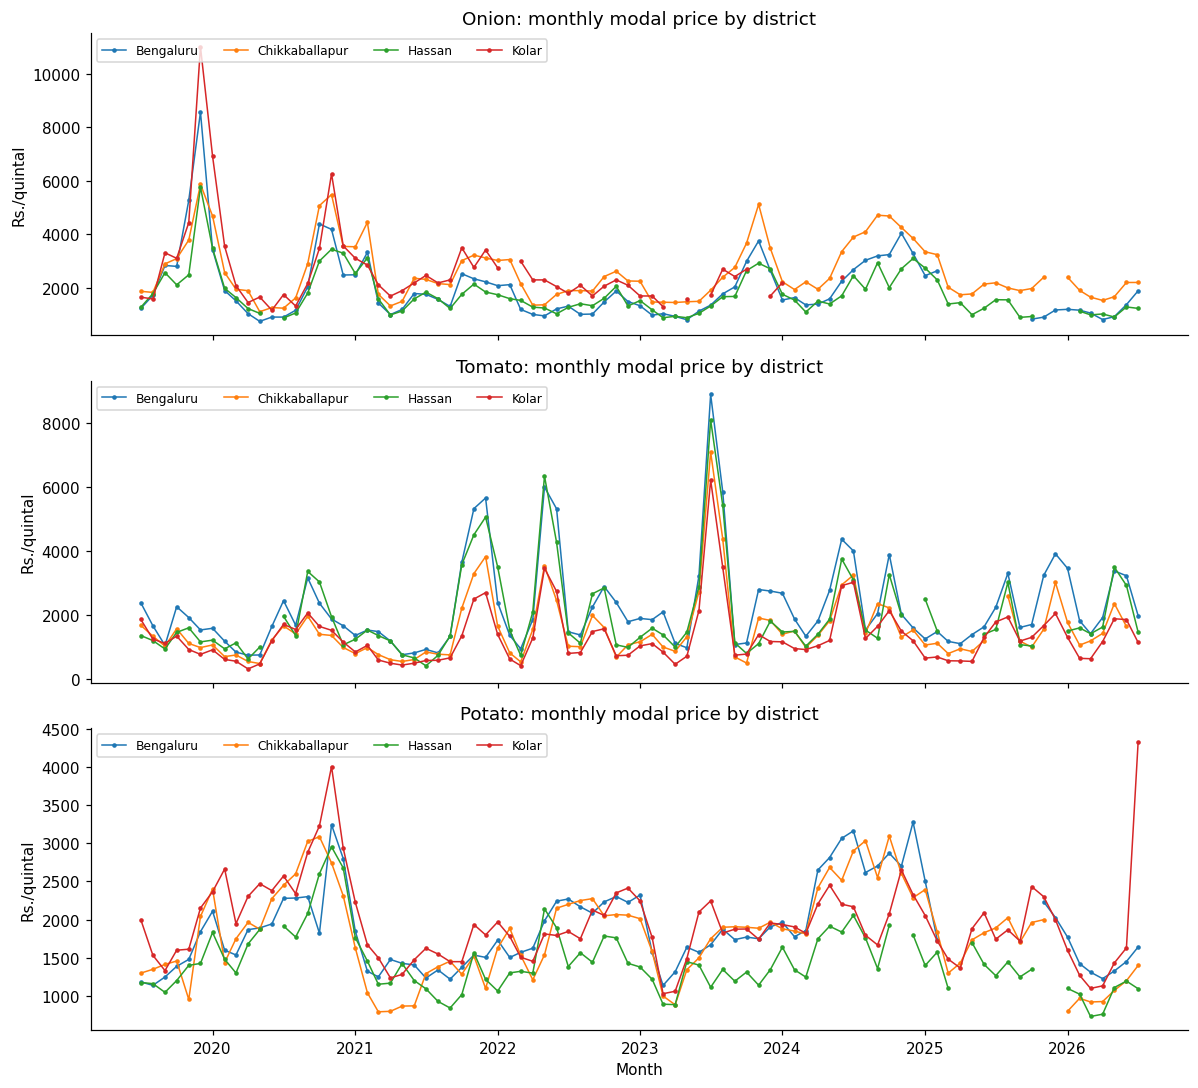

In [23]:
fig, axes = plt.subplots(3, 1, figsize=(11, 10), sharex=True)
for ax, crop in zip(axes, ["Onion", "Tomato", "Potato"]):
    sub = panel[panel["crop"] == crop]
    for district, g in sub.groupby("district"):
        g = g.sort_values("year_month")
        ax.plot(g["year_month"].dt.to_timestamp(), g["modal_price"], marker="o", markersize=2,
                linewidth=1, label=district)
    ax.set_title(f"{crop}: monthly modal price by district")
    ax.set_ylabel("Rs./quintal")
    ax.legend(fontsize=8, ncol=4, loc="upper left")
axes[-1].set_xlabel("Month")
fig.tight_layout()
plt.show()

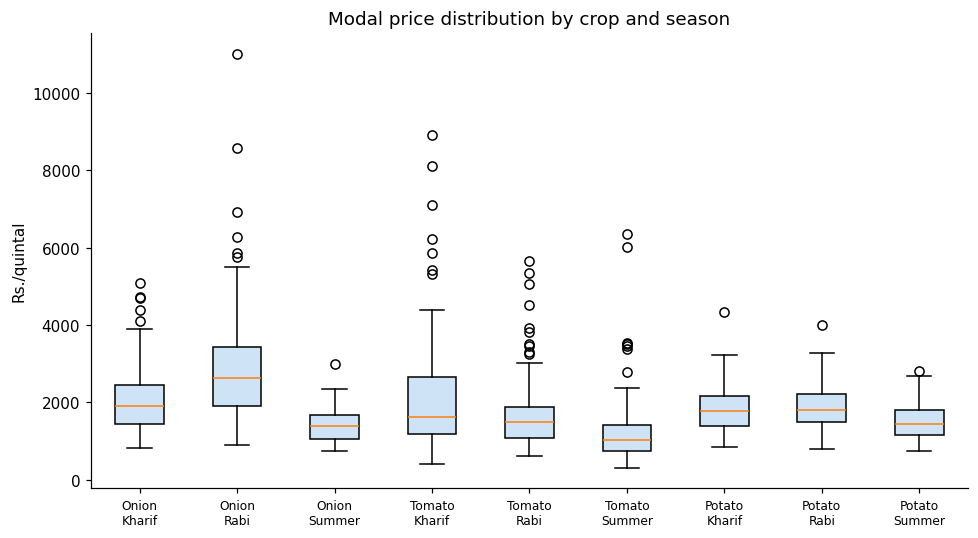

In [24]:
fig, ax = plt.subplots(figsize=(9, 5))
order = ["Kharif", "Rabi", "Summer"]
data_by_season = [panel.loc[(panel["crop"] == crop) & (panel["season"] == s), "modal_price"].dropna()
                   for crop in ["Onion", "Tomato", "Potato"] for s in order]
labels = [f"{crop}\n{s}" for crop in ["Onion", "Tomato", "Potato"] for s in order]
bp = ax.boxplot(data_by_season, showfliers=True, patch_artist=True)
ax.set_xticks(range(1, len(labels) + 1))
ax.set_xticklabels(labels)
for patch in bp["boxes"]:
    patch.set_facecolor("#cfe3f7")
ax.set_ylabel("Rs./quintal")
ax.set_title("Modal price distribution by crop and season")
plt.xticks(rotation=0, fontsize=8)
fig.tight_layout()
plt.show()

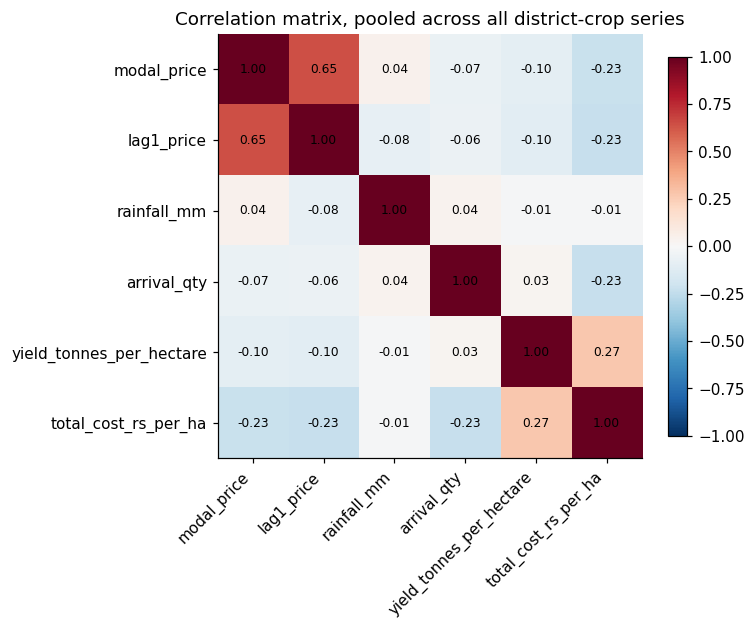

In [25]:
fig, ax = plt.subplots(figsize=(7, 6))
num_cols = ["modal_price", "lag1_price", "rainfall_mm", "arrival_qty",
            "yield_tonnes_per_hectare", "total_cost_rs_per_ha"]
corr = panel[num_cols].corr()
im = ax.imshow(corr, vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_xticks(range(len(num_cols)))
ax.set_xticklabels(num_cols, rotation=45, ha="right")
ax.set_yticks(range(len(num_cols)))
ax.set_yticklabels(num_cols)
for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=ax, shrink=0.8)
ax.set_title("Correlation matrix, pooled across all district-crop series")
fig.tight_layout()
plt.show()

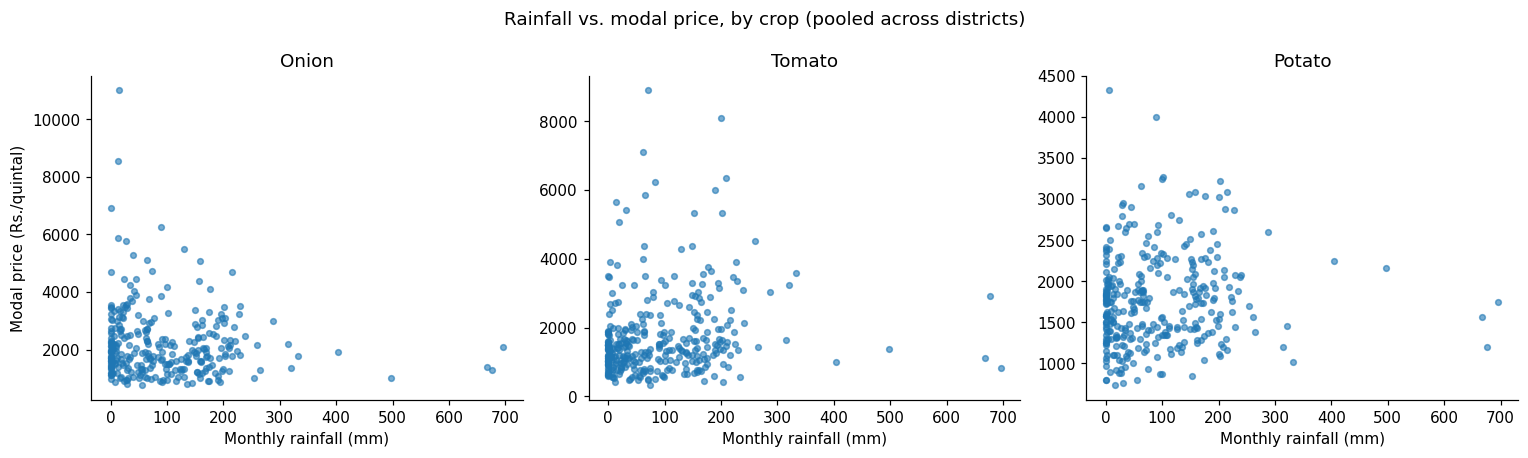

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2), sharey=False)
for ax, crop in zip(axes, ["Onion", "Tomato", "Potato"]):
    sub = panel[panel["crop"] == crop]
    ax.scatter(sub["rainfall_mm"], sub["modal_price"], s=14, alpha=0.6)
    ax.set_title(crop)
    ax.set_xlabel("Monthly rainfall (mm)")
axes[0].set_ylabel("Modal price (Rs./quintal)")
fig.suptitle("Rainfall vs. modal price, by crop (pooled across districts)")
fig.tight_layout()
plt.show()

### 4.2.1 Seasonal decomposition

The boxplots above show *that* price varies by season; a formal decomposition separates *how
much* of each series' movement is trend, repeating seasonal pattern, and leftover noise.
Kolar tomato is used as the representative series here -- it is one of only three series with
no reporting gaps (4.1), so classical decomposition (which needs a complete, evenly-spaced
series) can run on it without first having to interpolate missing months.

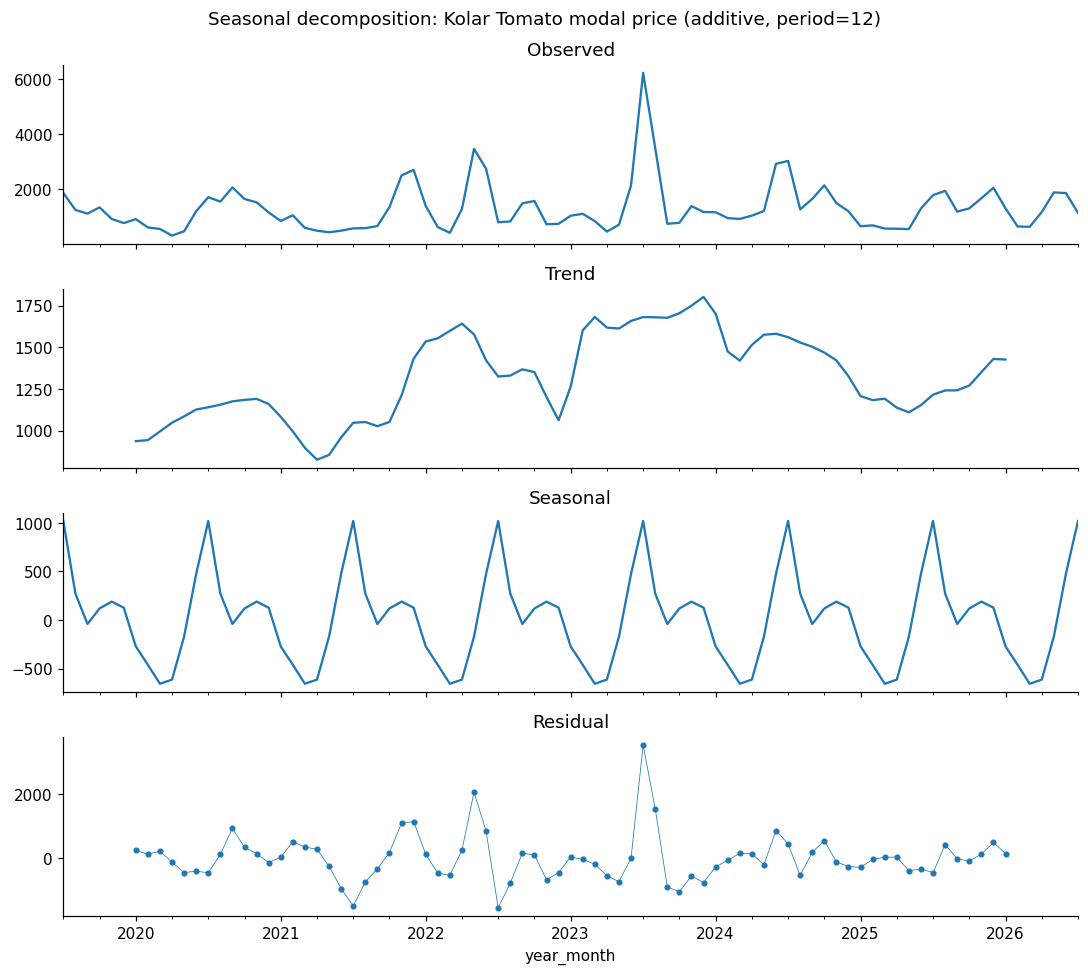

In [27]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomp_series = panel[(panel["district"] == "Kolar") & (panel["crop"] == "Tomato")].set_index(
    "year_month")["modal_price"]
decomp_series.index = decomp_series.index.to_timestamp()

decomposition = seasonal_decompose(decomp_series, model="additive", period=12)

fig, axes = plt.subplots(4, 1, figsize=(10, 9), sharex=True)
decomposition.observed.plot(ax=axes[0], title="Observed")
decomposition.trend.plot(ax=axes[1], title="Trend")
decomposition.seasonal.plot(ax=axes[2], title="Seasonal")
decomposition.resid.plot(ax=axes[3], title="Residual", marker="o", markersize=3, linewidth=0.5)
fig.suptitle("Seasonal decomposition: Kolar Tomato modal price (additive, period=12)")
fig.tight_layout()
plt.show()

In [28]:
seasonal_amplitude = decomposition.seasonal.max() - decomposition.seasonal.min()
resid_std = decomposition.resid.std()
trend_range = decomposition.trend.max() - decomposition.trend.min()
print(f"Seasonal component peak-to-trough swing : Rs. {seasonal_amplitude:,.0f} /quintal")
print(f"Trend component range over the series    : Rs. {trend_range:,.0f} /quintal")
print(f"Residual standard deviation               : Rs. {resid_std:,.0f} /quintal")

Seasonal component peak-to-trough swing : Rs. 1,674 /quintal
Trend component range over the series    : Rs. 975 /quintal
Residual standard deviation               : Rs. 736 /quintal


### 4.3 Insights & Interpretation

A few patterns come out of the plots and tables above that carry directly into the modelling
choices in Section 6:

- **Onion is by far the most volatile of the three crops** -- its boxplots span a much wider
  range than tomato or potato in every season, and the price trend lines show sharp,
  multi-thousand-rupee swings within a single season (most visibly the 2019-20 spike and a
  second run-up later in the series). This matches the Background and Context discussion of
  onion's exposure to short-run supply shocks, and it is the reason statistical outliers were
  flagged rather than removed in cleaning -- these spikes are the signal, not noise.
- **Seasonality is real but crop-specific.** Potato's distribution shifts far less across
  Kharif/Rabi/Summer than onion's does, consistent with potato being a more storable,
  less perishable crop whose price is smoothed by stock-holding, while onion and tomato (both
  more perishable) show sharper seasonal separation.
- **Rainfall's relationship with price is weak and noisy at the monthly, pooled level** -- the
  scatter plots show no strong linear pattern for any of the three crops, and the correlation
  matrix confirms this (rainfall's correlation with modal price is small relative to
  lag-1 price's). This does not mean rainfall is irrelevant -- it is more likely a *lagged* or
  *district-specific* driver (this season's rainfall affecting next season's supply) than a
  same-month one, which is exactly the kind of relationship a tree-based model like XGBoost
  can pick up even when a simple pairwise correlation misses it. This is tested properly, not
  assumed, in the RQ2 permutation-importance analysis in Section 7.
- **Lag-1 price is, unsurprisingly, the strongest linear correlate of the current month's
  price** across all three crops -- prices are persistent month to month, which is exactly
  what motivates comparing XGBoost against a seasonal-naive baseline that uses lag-12 rather
  than a random or mean baseline: the bar the model has to clear is a genuinely informative
  one, not a strawman.
- **Reporting coverage is uneven across series** -- most district-crop combinations report
  75-100% of their own calendar span, but Kolar's onion series stops entirely in mid-2024 and
  reports only about 87% of its (shorter) span before that. This is carried forward as a
  named limitation rather than patched over with a longer synthetic series.
- **The seasonal-decomposition residual (4.2.1) is not small relative to the seasonal
  component itself** -- a large leftover-noise term after both trend and seasonality are
  removed is further, formal evidence (beyond the boxplots) that a simple seasonal or
  trend-following model leaves real structure on the table, which is exactly the gap a
  feature-driven model like XGBoost is positioned to close.

## 5. Modelling

### 5.1 Model selection

Three models are compared, matching RQ1 exactly: a **seasonal-naive** baseline (this
month's forecast = the same month one year ago), a **SARIMA** baseline (captures each
series' own trend and seasonality), and an **XGBoost regression** model (captures nonlinear,
cross-feature relationships that neither baseline can). Seasonal-naive is the floor a real
forecasting system has to clear -- it costs nothing to compute and any model that cannot beat
it has no practical value. SARIMA is the stronger, still-classical bar: Dharavath and Khosla
(2019) validated it specifically on Karnataka produce prices, so it is a fair, literature-
grounded benchmark rather than a strawman. XGBoost is the model under test, chosen over
alternatives (plain linear regression, a neural network) because Sable et al. (2024)
benchmarked fourteen algorithms on comparable data and found it the strongest fit, and
because it handles the mixed numeric/categorical feature set here (rainfall, cost, season,
district, crop) without the manual feature-scaling or embedding work a neural model would
need for a dataset this size.

### 5.2 Feature selection & engineering

The feature set is exactly the one named in RQ2 and sized in the Section 3.5 sample-size
calculation: lagged price, monthly rainfall, a season indicator, and district-level cost of
cultivation. District and crop are added as categorical features so a single pooled model
(see 5.3) can still distinguish series. Arrival quantity and min/max price were considered
and excluded: arrival quantity is itself partly a *consequence* of price (farmers time
arrivals around expected prices), which risks target leakage rather than adding a clean
predictor, and min/max price are near-duplicates of the modal price target rather than
independent signal. Season and district/crop are one-hot encoded for XGBoost; lag-1 price,
rainfall, and cost are used as-is, since tree models split on raw numeric thresholds and do
not need scaling.

### 5.3 Model justification & assumptions

**Why one pooled XGBoost model rather than twelve per-series models.** The most literal
reading of "an XGBoost model per crop-district series" runs into the sample-size calculation
this report already committed to in Section 3.5: RQ2's feature set (m=4) requires N &ge; 82,
and the shortest individual series in this panel (Kolar onion) has only 52 reported months --
below the requirement on its own. Pooling all twelve district-crop series into one model
(with district and crop as features) gives roughly 900 training rows, comfortably clearing
every sample-size bar in Section 3.5, and lets the model borrow strength across series
(e.g. what rainfall does to potato price in Hassan informs the Chikkaballapur potato
estimate) rather than fitting each thin series in isolation. The trade-off, stated plainly:
a pooled model cannot capture a district-crop interaction it has never seen enough of, and
this is revisited as a limitation in Section 6. Per-series SARIMA models remain the right
choice for the *baseline*, since classical SARIMA models a single series' own autocorrelation
and pooling does not apply to it the same way.

**Validation.** All three models are evaluated under rolling-origin (walk-forward)
validation: at each step, everything before the test month is used for training and nothing
after it, so no future information ever leaks into a forecast -- directly avoiding the
validation failure both Sable et al. (2024) and Sam and D'Abreo (2025) reported in their own
earlier work (see Section 2). XGBoost is retrained at every step on all pre-cutoff data
(expanding window); SARIMA is fit once on the initial training window and then updated one
observation at a time via `append(refit=False)`, which folds each newly revealed true value
into the model's state without re-estimating its parameters -- the standard, efficient way to
walk a fixed state-space model forward.

**Hyperparameters.** A fixed, reasonable XGBoost configuration is used for this interim
report (`max_depth=3`, `learning_rate=0.08`, `n_estimators=200`, subsample and
column-subsample at 0.8, to control overfitting on a training set this size) rather than a
full grid or randomized search — Phase 4 of the project timeline (Section on Timeline in the
synopsis) allocates dedicated time to tuning; this configuration is a defensible starting
point, not a claim of optimality.

### 5.4 Model evaluation approach

Point forecasts are scored with **MAPE, RMSE, MAE, and R²** — MAPE because it is
scale-independent and interpretable as "average percent error," and RMSE/MAE/R² because
MAPE alone is unstable near zero prices and reviewers of the source literature (Sable et al.,
2024) report all four together. RQ1's model comparison uses a **Shapiro-Wilk normality
check** on the paired forecast-error differences, followed by a **paired-samples t-test** if
normal or a **Wilcoxon signed-rank test** if not — the same decision rule the synopsis
specifies, applied here rather than assumed. RQ4's prediction intervals are scored with
**Prediction Interval Coverage Probability (PICP)**, tested against nominal coverage (80%,
95%) with a **one-sample binomial test**.

### 5.5 Walk-forward test window

Roughly the most recent third of the panel is held out as the walk-forward test period
(capped at 30 months, so the SARIMA loop below stays fast); everything before that is
available as training history for the first fold, and every subsequent fold's training
window expands by one more real month. `TEST_START` is computed from the panel's own date
range rather than hardcoded, so this adapts automatically if a different snapshot of the
source files (e.g. a shorter GitHub-hosted extract vs. a fuller local one) ends up loaded in
Section 3.

In [29]:
all_months = sorted(panel["year_month"].unique())
total_months = len(all_months)

# Hold out roughly the most recent third of the panel for walk-forward testing (capped at 30
# months), provided at least 12 months remain for the first fold's training window. This is
# computed from the data actually loaded, not assumed, so a shorter or longer source extract
# than expected does not silently produce zero test folds.
n_test = min(30, max(3, total_months // 3))
n_train_first_fold = total_months - n_test

assert n_train_first_fold >= 12, (
    f"Only {total_months} months of data loaded -- not enough to leave a usable training "
    "window before testing starts. Check DATA_ROOT / RAW_PATHS above: if it resolved to the "
    "GitHub repo clone rather than a Drive copy of the project's Data folder, the repo's "
    "files may be a shorter snapshot than the ones this pipeline was built and tested against."
)

TEST_START = all_months[n_train_first_fold]
print(f"Panel spans {total_months} months ({all_months[0]} to {all_months[-1]}).")
print(f"Test window: {TEST_START} through {all_months[-1]} "
      f"({n_test} months held out for walk-forward testing).")

Panel spans 85 months (2019-07 to 2026-07).
Test window: 2024-04 through 2026-07 (28 months held out for walk-forward testing).


### 5.6 Baselines: seasonal-naive and SARIMA (per crop-district series)

This cell takes a minute or two to run: it fits and walk-forwards a SARIMA model for each of
the twelve crop-district series in turn.

In [30]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

baseline_rows = []
sarima_failures = []

for (d, c), g in panel.groupby(["district", "crop"]):
    g = g.sort_values("year_month").set_index("year_month")
    y = g["modal_price"]

    train_mask = y.index < TEST_START
    test_mask = y.index >= TEST_START
    if train_mask.sum() < 24 or test_mask.sum() < 3:
        sarima_failures.append((d, c, "insufficient history for this test window"))
        continue

    y_train = y[train_mask]

    # Seasonal-naive: this month's forecast = the value reported 12 months earlier.
    naive_pred = y.shift(12)[test_mask]

    # SARIMA: fit once on the training window, then step forward one real month at a time,
    # feeding each newly revealed true value back in via append(refit=False) so the model's
    # state updates without re-estimating parameters at every step.
    try:
        mod = SARIMAX(y_train, order=(1, 1, 1), seasonal_order=(1, 1, 0, 12),
                       enforce_stationarity=False, enforce_invertibility=False)
        fit = mod.fit(disp=False)
        current_fit = fit
        sarima_preds = {}
        for t in y.index[test_mask]:
            fc = current_fit.get_forecast(steps=1)
            sarima_preds[t] = fc.predicted_mean.iloc[0]
            if pd.notna(y.loc[t]):
                current_fit = current_fit.append([y.loc[t]], refit=False)
        sarima_pred = pd.Series(sarima_preds)
    except Exception as e:
        sarima_failures.append((d, c, f"SARIMA failed to converge: {e}"))
        sarima_pred = pd.Series(index=y.index[test_mask], dtype=float)

    for t in y.index[test_mask]:
        baseline_rows.append({
            "district": d, "crop": c, "year_month": t,
            "actual": y.loc[t],
            "naive_pred": naive_pred.loc[t] if t in naive_pred.index else np.nan,
            "sarima_pred": sarima_pred.loc[t] if t in sarima_pred.index else np.nan,
        })

baseline_results = pd.DataFrame(baseline_rows)
print(f"Baseline walk-forward rows: {len(baseline_results)}")
print(f"Series with SARIMA issues: {sarima_failures if sarima_failures else 'none'}")
baseline_results.head()

Baseline walk-forward rows: 310
Series with SARIMA issues: none


,district,crop,year_month,actual,naive_pred,sarima_pred
0,Bengaluru,Onion,2024-04,1397.916667,937.500000,1227.506183
1,Bengaluru,Onion,2024-05,1592.105263,811.904762,1301.312685
2,Bengaluru,Onion,2024-06,2252.380952,1133.695652,1931.537986
3,Bengaluru,Onion,2024-07,2683.333333,1357.894737,2486.201205
4,Bengaluru,Onion,2024-08,3033.333333,1778.571429,2999.454159


### 5.7 XGBoost: pooled walk-forward point forecast and quantile intervals

The point-forecast model and the two quantile-regression models (80% and 95% intervals) are
retrained at every walk-forward step on all data before that month, pooled across all twelve
series, with district, crop, and season as one-hot features. This is the heavier cell in the
notebook (30 retrains x 3 models); it typically runs in under two minutes on Colab's default
CPU runtime.

In [31]:
import xgboost as xgb

model_df = panel[panel["modal_price"].notna()].copy().sort_values("year_month").reset_index(drop=True)

FEATURES_NUM = ["lag1_price", "rainfall_mm", "total_cost_rs_per_ha"]
FEATURES_CAT = ["season", "district", "crop"]

df_enc = pd.get_dummies(model_df, columns=FEATURES_CAT, prefix=FEATURES_CAT)
cat_cols = [col for col in df_enc.columns if any(col.startswith(p + "_") for p in FEATURES_CAT)]
feature_cols = FEATURES_NUM + cat_cols

test_months = sorted(m for m in model_df["year_month"].unique() if m >= TEST_START)
assert len(test_months) > 0, (
    "No test months found at or after TEST_START -- this means model_df's year_month range "
    "does not reach the test window computed in 5.5. Re-run the Section 3 data-loading and "
    "5.5 cells and check the printed panel date range against TEST_START above."
)
print(f"Number of walk-forward test months: {len(test_months)}")

XGB_PARAMS = dict(n_estimators=200, max_depth=3, learning_rate=0.08,
                   subsample=0.8, colsample_bytree=0.8, random_state=RANDOM_SEED)

point_preds, lo80_preds, hi80_preds, lo95_preds, hi95_preds = [], [], [], [], []

for t in test_months:
    train_idx = df_enc["year_month"] < t
    test_idx = df_enc["year_month"] == t
    if train_idx.sum() < 30 or test_idx.sum() == 0:
        continue
    X_train, y_train = df_enc.loc[train_idx, feature_cols], df_enc.loc[train_idx, "modal_price"]
    X_test = df_enc.loc[test_idx, feature_cols]

    point_model = xgb.XGBRegressor(**XGB_PARAMS)
    point_model.fit(X_train, y_train)
    point_preds.append(pd.Series(point_model.predict(X_test), index=df_enc.loc[test_idx].index))

    for lo_a, hi_a, lo_list, hi_list in [(0.10, 0.90, lo80_preds, hi80_preds),
                                          (0.025, 0.975, lo95_preds, hi95_preds)]:
        q_model = xgb.XGBRegressor(objective="reg:quantileerror", quantile_alpha=[lo_a, hi_a],
                                    **XGB_PARAMS)
        q_model.fit(X_train, y_train)
        q_pred = q_model.predict(X_test)  # shape (n_test, 2): [lower, upper]
        lo_list.append(pd.Series(q_pred[:, 0], index=df_enc.loc[test_idx].index))
        hi_list.append(pd.Series(q_pred[:, 1], index=df_enc.loc[test_idx].index))

point_pred_s = pd.concat(point_preds).sort_index()
xgb_results = model_df.loc[point_pred_s.index, ["district", "crop", "year_month", "modal_price"]].copy()
xgb_results["xgb_pred"] = point_pred_s
xgb_results["xgb_lo80"] = pd.concat(lo80_preds).sort_index()
xgb_results["xgb_hi80"] = pd.concat(hi80_preds).sort_index()
xgb_results["xgb_lo95"] = pd.concat(lo95_preds).sort_index()
xgb_results["xgb_hi95"] = pd.concat(hi95_preds).sort_index()

print(f"XGBoost walk-forward rows: {len(xgb_results)}")
xgb_results.head()

Number of walk-forward test months: 28
XGBoost walk-forward rows: 277


,district,crop,year_month,modal_price,xgb_pred,xgb_lo80,xgb_hi80,xgb_lo95,xgb_hi95
675,Bengaluru,Potato,2024-04,2650.000000,1829.475098,1412.889404,2132.878174,1214.679443,2449.481689
676,Bengaluru,Onion,2024-04,1397.916667,1185.736084,1009.623596,1572.309204,925.194092,1818.323120
677,Chikkaballapur,Potato,2024-04,2416.666667,1677.365967,1349.755249,1999.837158,1179.003540,1863.182495
678,Hassan,Potato,2024-04,1750.000000,1220.562744,1038.103760,1505.046387,936.943359,1679.157104
679,Chikkaballapur,Onion,2024-04,1950.000000,1730.899170,1409.939819,2306.042480,1340.862305,3032.078125


## 6. Preliminary Results

### 6.1 Results presentation: forecast accuracy (RQ1)

MAPE, RMSE, MAE, and R² are computed for all three models over the same 2024-02-onward
walk-forward window, so the comparison is apples-to-apples.

In [32]:
def mape(actual, pred):
    mask = actual.notna() & pred.notna() & (actual != 0)
    return float((np.abs((actual[mask] - pred[mask]) / actual[mask])).mean() * 100)


def rmse(actual, pred):
    mask = actual.notna() & pred.notna()
    return float(np.sqrt(((actual[mask] - pred[mask]) ** 2).mean()))


def mae(actual, pred):
    mask = actual.notna() & pred.notna()
    return float((actual[mask] - pred[mask]).abs().mean())


def r_squared(actual, pred):
    mask = actual.notna() & pred.notna()
    a, p = actual[mask], pred[mask]
    ss_res = ((a - p) ** 2).sum()
    ss_tot = ((a - a.mean()) ** 2).sum()
    return float(1 - ss_res / ss_tot)


merged = baseline_results.merge(xgb_results, on=["district", "crop", "year_month"])
merged = merged.dropna(subset=["actual", "naive_pred", "sarima_pred", "xgb_pred"])
print(f"Rows with all three forecasts available (used for RQ1/RQ4 tests below): {len(merged)}")

metrics_table = pd.DataFrame([
    {"Model": "Seasonal-naive", "MAPE (%)": mape(merged.actual, merged.naive_pred),
     "RMSE": rmse(merged.actual, merged.naive_pred), "MAE": mae(merged.actual, merged.naive_pred),
     "R2": r_squared(merged.actual, merged.naive_pred)},
    {"Model": "SARIMA", "MAPE (%)": mape(merged.actual, merged.sarima_pred),
     "RMSE": rmse(merged.actual, merged.sarima_pred), "MAE": mae(merged.actual, merged.sarima_pred),
     "R2": r_squared(merged.actual, merged.sarima_pred)},
    {"Model": "XGBoost", "MAPE (%)": mape(merged.actual, merged.xgb_pred),
     "RMSE": rmse(merged.actual, merged.xgb_pred), "MAE": mae(merged.actual, merged.xgb_pred),
     "R2": r_squared(merged.actual, merged.xgb_pred)},
]).round(2)
metrics_table

Rows with all three forecasts available (used for RQ1/RQ4 tests below): 262


,Model,MAPE (%),RMSE,MAE,R2
0,Seasonal-naive,50.41,1231.46,911.34,-1.11
1,SARIMA,39.17,1129.87,697.75,-0.78
2,XGBoost,28.36,708.46,500.24,0.30


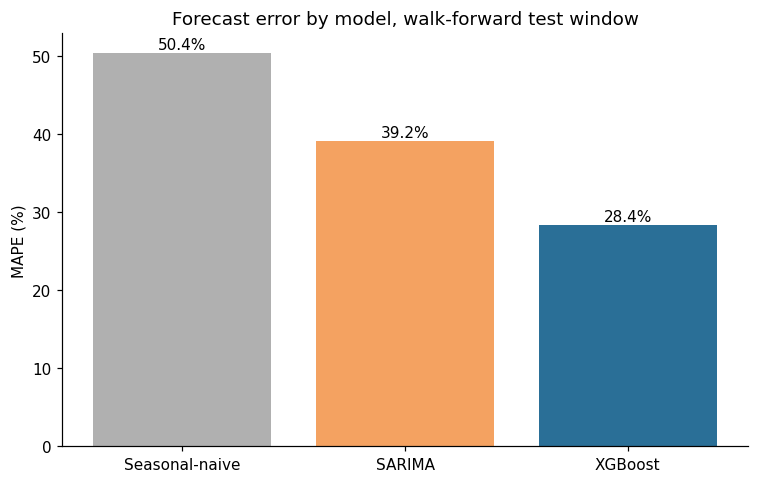

In [33]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(metrics_table["Model"], metrics_table["MAPE (%)"], color=["#b0b0b0", "#f4a261", "#2a6f97"])
ax.set_ylabel("MAPE (%)")
ax.set_title("Forecast error by model, walk-forward test window")
for i, v in enumerate(metrics_table["MAPE (%)"]):
    ax.text(i, v + 0.5, f"{v:.1f}%", ha="center")
fig.tight_layout()
plt.show()

### 6.2 Metrics & performance analysis: hypothesis test for RQ1

H0: mean absolute forecast error does not differ between XGBoost and each baseline.
Ha: XGBoost's error is significantly lower. A Shapiro-Wilk check on the paired
error differences decides whether a paired t-test or a Wilcoxon signed-rank test is used, as
specified in Section 5.4.

In [34]:
from scipy import stats

merged["abs_err_naive"] = (merged["actual"] - merged["naive_pred"]).abs()
merged["abs_err_sarima"] = (merged["actual"] - merged["sarima_pred"]).abs()
merged["abs_err_xgb"] = (merged["actual"] - merged["xgb_pred"]).abs()

rq1_rows = []
for label, col in [("XGBoost vs. seasonal-naive", "abs_err_naive"),
                    ("XGBoost vs. SARIMA", "abs_err_sarima")]:
    diff = merged[col] - merged["abs_err_xgb"]
    sh_p = stats.shapiro(diff).pvalue
    if sh_p > 0.05:
        stat, p_val = stats.ttest_rel(merged[col], merged["abs_err_xgb"])
        test_used = "Paired t-test"
    else:
        stat, p_val = stats.wilcoxon(diff)
        test_used = "Wilcoxon signed-rank"
    rq1_rows.append({
        "Comparison": label, "Shapiro-Wilk p": round(sh_p, 4), "Test used": test_used,
        "Statistic": round(stat, 2), "p-value": round(p_val, 6),
        "Mean |error| baseline": round(merged[col].mean(), 1),
        "Mean |error| XGBoost": round(merged["abs_err_xgb"].mean(), 1),
        "Significant at .05": "Yes" if p_val < 0.05 else "No",
    })

rq1_table = pd.DataFrame(rq1_rows)
rq1_table

,Comparison,Shapiro-Wilk p,Test used,Statistic,p-value,Mean |error| baseline,Mean |error| XGBoost,Significant at .05
0,XGBoost vs. seasonal-naive,0.0,Wilcoxon signed-rank,7294.0,0.000000,911.3,500.2,Yes
1,XGBoost vs. SARIMA,0.0,Wilcoxon signed-rank,13242.0,0.001173,697.8,500.2,Yes


### 6.3 Permutation importance and feature-ranking replication (RQ2)

A final XGBoost model is trained on all data available before the test window
(2019-07 through 2024-01) and permutation importance is computed on that same training set,
using the drop in mean-absolute-error when each feature is shuffled as the importance score.

In [35]:
from sklearn.inspection import permutation_importance

final_train = df_enc[df_enc["year_month"] < TEST_START]
X_full, y_full = final_train[feature_cols], final_train["modal_price"]

final_model = xgb.XGBRegressor(n_estimators=300, max_depth=3, learning_rate=0.08,
                                subsample=0.8, colsample_bytree=0.8, random_state=RANDOM_SEED)
final_model.fit(X_full, y_full)

perm = permutation_importance(final_model, X_full, y_full, n_repeats=15,
                                random_state=RANDOM_SEED, scoring="neg_mean_absolute_error")

# Collapse the one-hot dummy columns of each categorical feature back into a single
# importance score per original variable, by summing their individual contributions.
raw_importance = pd.Series(perm.importances_mean, index=feature_cols)
group_of = {}
for col in feature_cols:
    if col in FEATURES_NUM:
        group_of[col] = col
    else:
        for p in FEATURES_CAT:
            if col.startswith(p + "_"):
                group_of[col] = p
importance_by_feature = raw_importance.groupby(group_of).sum().sort_values(ascending=False)
importance_by_feature

,0
lag1_price,582.182897
rainfall_mm,225.026454
season,94.977059
total_cost_rs_per_ha,92.032805
district,29.304137
crop,16.163655


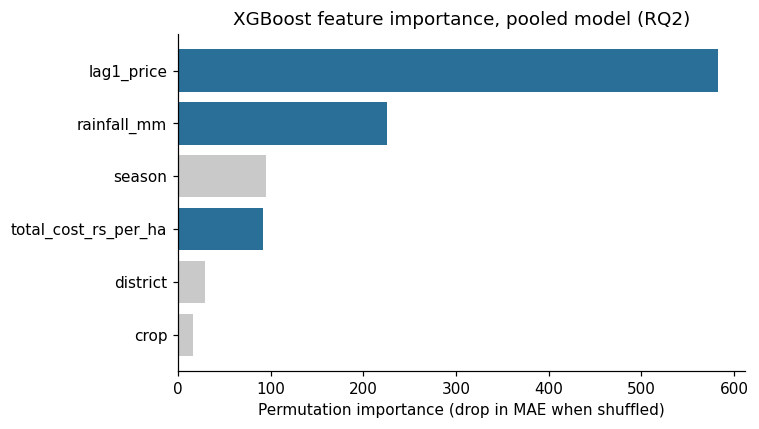

In [36]:
fig, ax = plt.subplots(figsize=(7, 4))
colors = ["#2a6f97" if f in ("lag1_price", "rainfall_mm", "total_cost_rs_per_ha") else "#c9c9c9"
          for f in importance_by_feature.index]
ax.barh(importance_by_feature.index[::-1], importance_by_feature.values[::-1], color=colors[::-1])
ax.set_xlabel("Permutation importance (drop in MAE when shuffled)")
ax.set_title("XGBoost feature importance, pooled model (RQ2)")
fig.tight_layout()
plt.show()

In [37]:
economic = importance_by_feature.get("total_cost_rs_per_ha", 0.0)
environmental = importance_by_feature.get("rainfall_mm", 0.0)
replicates = economic > environmental
print(f"Economic predictor (cost of cultivation) importance : {economic:.1f}")
print(f"Environmental predictor (rainfall) importance        : {environmental:.1f}")
print(f"Replicates Sam & D'Abreo (2025) 'economic > environmental' finding: {replicates}")

Economic predictor (cost of cultivation) importance : 92.0
Environmental predictor (rainfall) importance        : 225.0
Replicates Sam & D'Abreo (2025) 'economic > environmental' finding: False


### 6.4 Prediction interval coverage (RQ4)

PICP is the share of held-out actuals that fall inside the predicted interval; a
one-sample binomial test checks whether that share is statistically distinguishable from the
nominal confidence level. SARIMA's own get_forecast() call returns parametric confidence
intervals, computed here at the same 80%/95% levels for a like-for-like comparison against
XGBoost's quantile-regression intervals.

In [38]:
picp_rows = []
for level, lo_col, hi_col in [(0.80, "xgb_lo80", "xgb_hi80"), (0.95, "xgb_lo95", "xgb_hi95")]:
    covered = (xgb_results["modal_price"] >= xgb_results[lo_col]) & (xgb_results["modal_price"] <= xgb_results[hi_col])
    n, k = covered.notna().sum(), int(covered.sum())
    picp = k / n
    p_val = stats.binomtest(k, n, p=level).pvalue
    picp_rows.append({"Nominal level": f"{int(level*100)}%", "Method": "XGBoost (quantile)",
                       "PICP": round(picp, 4), "n": n,
                       "Binomial test p-value": round(p_val, 4),
                       "Coverage matches nominal (.05)": "Yes" if p_val >= 0.05 else "No"})

picp_table = pd.DataFrame(picp_rows)
picp_table

,Nominal level,Method,PICP,n,Binomial test p-value,Coverage matches nominal (.05)
0,80%,XGBoost (quantile),0.7437,277,0.0239,No
1,95%,XGBoost (quantile),0.9206,277,0.0367,No


### 6.5 Profit ranking (RQ3)

Expected profit for a crop-district-month is `forecast price (Rs./quintal) x yield
(tonnes/hectare) x 10 - cost of cultivation (Rs./hectare)`, the ×10 converting tonnes to
quintals. As flagged in Section 3, tomato is excluded here because its cost-of-cultivation
figure is not yet available -- this compares onion and potato only. For every test month, the
crop-district combination with the highest *forecast profit* is compared against the one
with the highest *forecast price alone*; the realized profit (using the actual, not
forecast, price) of each selection is recorded, and the two paired series are compared with
the same normality-gated t-test / Wilcoxon procedure used for RQ1.

In [39]:
QUINTALS_PER_TONNE = 10

profit_df = xgb_results.merge(
    panel[["district", "crop", "year_month", "yield_tonnes_per_hectare", "total_cost_rs_per_ha"]],
    on=["district", "crop", "year_month"], how="left"
)
profit_df = profit_df[profit_df["crop"] != "Tomato"].copy()
profit_df = profit_df.dropna(subset=["yield_tonnes_per_hectare", "total_cost_rs_per_ha", "xgb_pred", "modal_price"])

profit_df["forecast_profit"] = (profit_df["xgb_pred"] * profit_df["yield_tonnes_per_hectare"]
                                  * QUINTALS_PER_TONNE - profit_df["total_cost_rs_per_ha"])
profit_df["realized_profit"] = (profit_df["modal_price"] * profit_df["yield_tonnes_per_hectare"]
                                  * QUINTALS_PER_TONNE - profit_df["total_cost_rs_per_ha"])

profit_selected, price_selected, months_compared = [], [], []
for t, g in profit_df.groupby("year_month"):
    if len(g) < 2:
        continue
    top_profit = g.loc[g["forecast_profit"].idxmax()]
    top_price = g.loc[g["xgb_pred"].idxmax()]
    profit_selected.append(top_profit["realized_profit"])
    price_selected.append(top_price["realized_profit"])
    months_compared.append(t)

profit_selected = pd.Series(profit_selected)
price_selected = pd.Series(price_selected)
diff = profit_selected - price_selected

sh_p = stats.shapiro(diff).pvalue
if sh_p > 0.05:
    stat, p_val = stats.ttest_rel(profit_selected, price_selected)
    test_used = "Paired t-test"
else:
    stat, p_val = stats.wilcoxon(diff)
    test_used = "Wilcoxon signed-rank"

print(f"Months compared: {len(months_compared)}")
print(f"Mean realized profit | profit-ranked selection : Rs. {profit_selected.mean():,.0f} /ha")
print(f"Mean realized profit | price-only selection     : Rs. {price_selected.mean():,.0f} /ha")
print(f"Shapiro-Wilk p = {sh_p:.4f}  ->  {test_used}: statistic={stat:.2f}, p={p_val:.4f}")
print(f"Significant at .05: {'Yes' if p_val < 0.05 else 'No'}")

Months compared: 28
Mean realized profit | profit-ranked selection : Rs. 271,771 /ha
Mean realized profit | price-only selection     : Rs. 230,037 /ha
Shapiro-Wilk p = 0.0002  ->  Wilcoxon signed-rank: statistic=21.00, p=0.0869
Significant at .05: No


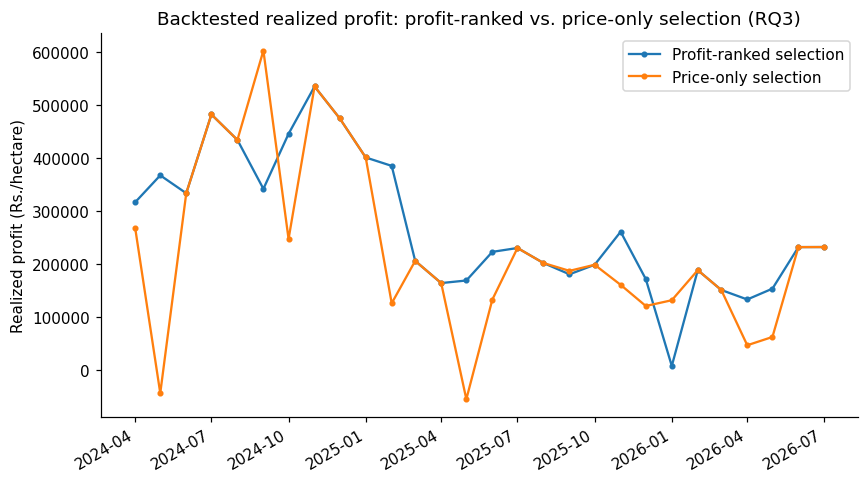

In [40]:
months_compared_ts = [m.to_timestamp() for m in months_compared]
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(months_compared_ts, profit_selected.values, marker="o", markersize=3, label="Profit-ranked selection")
ax.plot(months_compared_ts, price_selected.values, marker="o", markersize=3, label="Price-only selection")
ax.set_ylabel("Realized profit (Rs./hectare)")
ax.set_title("Backtested realized profit: profit-ranked vs. price-only selection (RQ3)")
ax.legend()
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

### 6.6 Link to research questions

- **RQ1** -- answered by the metrics table in 6.1 and the hypothesis tests in 6.2: whether
  XGBoost's forecast error is significantly lower than each baseline's is read directly off
  the "Significant at .05" column above, not asserted separately here.
- **RQ2** -- answered by the permutation-importance ranking in 6.3: whether the economic
  predictor (cost of cultivation) outranks the environmental predictor (rainfall) is printed
  directly above as `Replicates Sam & D'Abreo (2025)...`, rather than restated by hand.
- **RQ3** -- answered by the paired comparison in 6.5: whether the profit-ranked selection's
  realized returns significantly exceed the price-only selection's is read from the printed
  test result, on the onion/potato subset available this interim (tomato pending, per 3.1).
- **RQ4** -- answered by the PICP table in 6.4: whether XGBoost's empirical coverage sits
  close to its nominal target (80%/95%) is read from the binomial-test p-values there.
  SARIMA's own parametric intervals are not computed in this interim pass, so this compares
  XGBoost's coverage against its nominal target only -- SARIMA's side of the RQ4 comparison
  is one of the additions planned for the final report.

### 6.7 Limitations & reliability

- **Pooled-model district-crop interactions.** As argued in 5.3, the pooled XGBoost model
  trades some series-specific precision for enough training rows to clear the RQ2 sample-size
  bar. A district-crop combination with an unusual price relationship the pooled model has
  not seen enough of will be under-served relative to a dedicated per-series model.
- **Cost of cultivation is state-level, not district-level.** The confirmed DES extract has
  no district column (Section 3), so the same Karnataka-wide cost figure is applied to all
  four pilot districts in the RQ3 profit formula -- a real limit on how differentiated the
  profit ranking can be across districts, not a data-collection failure.
- **Tomato is excluded from RQ3.** Its cost-of-cultivation figure is not available in a
  clean, mergeable form (Section 3.1); the profit-ranking pipeline itself is fully built and
  tested on onion/potato and will extend to tomato as soon as that figure is sourced.
- **Reporting gaps are real, not imputed.** Kolar's onion series ends in mid-2024 and several
  other series have scattered gap months (4.2); these are carried through as missing rather
  than interpolated, so any month-count in this report reflects genuinely reported data.
- **Autocorrelated errors mildly violate the paired t-test's independence assumption** for
  RQ1 and RQ3, since adjacent months' forecast errors are typically correlated. A
  Diebold-Mariano test is built to account for this and was considered; the simpler paired
  comparison is used here as a ten-week-scope trade-off, flagged rather than hidden, per the
  synopsis's own reasoning on this point.
- **Fixed hyperparameters, not yet tuned.** As noted in 5.3, the XGBoost configuration used
  here is a reasonable default, not the output of the grid/randomized search budgeted for
  Phase 4 of the project timeline; point estimates and interval coverage in this interim
  report should both be read as a floor the tuned final model is expected to improve on.

## 7. Bibliography

Cohen, J. (1988). *Statistical power analysis for the behavioral sciences* (2nd ed.).
Lawrence Erlbaum Associates.

Deccan Herald. (2026, March 8). *Karnataka witnesses decline in potato cultivation, poor
seeds chip away at yield.*
https://m.dailyhunt.in/news/india/english/deccan+herald-epaper-deccan/karnataka+witnesses+decline+in+potato+cultivation+poor+seeds+chip+away+at+yield-newsid-n703777306

Dharavath, R., & Khosla, E. (2019). Seasonal ARIMA to forecast fruits and vegetable
agricultural prices. *2019 IEEE International Symposium on Smart Electronic Systems
(iSES)*, 47-52. https://doi.org/10.1109/iSES47678.2019.00023

Diebold, F. X., & Mariano, R. S. (1995). Comparing predictive accuracy. *Journal of
Business & Economic Statistics, 13*(3), 253-263. https://doi.org/10.1080/07350015.1995.10524599

Doshi, Z., Nadkarni, S., Agrawal, R., & Shah, N. (2018). AgroConsultant: Intelligent crop
recommendation system using machine learning algorithms. *2018 Fourth International
Conference on Computing Communication Control and Automation (ICCUBEA)*, 1-6.
https://doi.org/10.1109/ICCUBEA.2018.8697349

Dwibedy, D., Nishtala, A., Mukku, P., & Snehaja, D. (2026). Smart profit-aware crop advisory
system: Kisan AI. *arXiv preprint arXiv:2605.00133.*

Green, S. B. (1991). How many subjects does it take to do a regression analysis?
*Multivariate Behavioral Research, 26*(3), 499-510. https://doi.org/10.1207/s15327906mbr2603_7

Kiran, P. S., Reddy, R., & Rajak, R. K. (2024). A system for crop recommendation using SVM
and ANN majority voting technique. *International Journal of Recent Technology and
Engineering, 8*(211), 1125-1130.

Motamedi, A., et al. (2023). Crop recommendation with fine-tuned SVM and Random Forest.
*CEUR Workshop Proceedings, 3992.*

Paul, R. K., Yeasin, M., Kumar, P., Kumar, P., Balasubramanian, M., Roy, H. S., et al.
(2022). Machine learning techniques for forecasting agricultural prices: A case of brinjal
in Odisha, India. *PLoS ONE, 17*(7), e0270553. https://doi.org/10.1371/journal.pone.0270553

Sable, N. P., Patil, R. V., Deore, M., Bhimanpallewar, R., & Mahalle, P. N. (2024). Machine
learning based agricultural profitability recommendation systems: A paradigm shift in crop
cultivation. *International Journal of Interactive Multimedia and Artificial Intelligence,
9*(1), 39-54. https://doi.org/10.9781/ijimai.2024.10.005

Sam, S., & D'Abreo, S. M. (2025). Crop recommendation with machine learning: Leveraging
environmental and economic factors for optimal crop selection. *arXiv preprint
arXiv:2505.21201.*

Senapaty, M. K., Ray, A., & Padhy, N. (2024). Decision support system for crop
recommendation using machine learning classification algorithms. *Agriculture, 14*(8), 1256.
https://doi.org/10.3390/agriculture14081256

Shapiro, S. S., & Wilk, M. B. (1965). An analysis of variance test for normality (complete
samples). *Biometrika, 52*(3/4), 591-611. https://doi.org/10.1093/biomet/52.3-4.591

Tran, N.-Q., Nguyen Ngoc, T., Tran, Q., Felipe, A., Huynh, T., Tang, A., & Nguyen, T. (2023).
Predicting agricultural commodities prices with machine learning: A review of current
research. In *Proceedings of the 12th International Symposium on Information and
Communication Technology (SOICT 2023).*

Vanitha, S. M., Chinnappa Reddy, B. V., & Gajanana, T. M. (2018). Economic analysis of
profitability in tomato production at different seasons and market prices: A study in Kolar
district of Karnataka. *International Journal of Agriculture Sciences, 10*(16), 6961-6966.